# Desafío 2 — Situación 1: Validación factorial y Factor-Cluster Analysis

Este notebook desarrolla la **Situación 1** paso a paso usando Python. El objetivo es trabajar con un conjunto de datos de evaluación del LLM **NLA-7B**, donde cada fila representa un prompt y las columnas representan métricas heterogéneas: evaluaciones humanas, activaciones internas y medidas derivadas de rendimiento.

La situación plantea dos tareas principales:

1. Validar psicométricamente un sub-instrumento de **20 ítems de evaluación humana**, organizado teóricamente en cuatro constructos latentes: **Calidad, Seguridad, Creatividad y Sesgo**.
2. Aplicar una estrategia de **Análisis Factorial-Cluster**, reduciendo primero la dimensionalidad de la matriz completa y luego agrupando los prompts en perfiles tipológicos.

La estructura del notebook sigue este flujo:

**Carga de datos → CFA sobre evaluación humana → PCA/PC sobre todas las variables → rotación Varimax → clustering → perfilado e interpretación.**

In [3]:
# ============================================================
# 0. Configuración inicial
# ============================================================

# Estas variables ayudan a que algunas operaciones lineales sean más estables y rápidas
# en equipos donde OpenBLAS/MKL intenta usar demasiados hilos.
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.optimize import minimize
from scipy.stats import chi2
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

RUTA_DATOS = "neuro_lingua_ai.csv"
SEMILLA = 123

## 1. Carga e inspección general del conjunto de datos

Primero se carga el archivo y se verifica su estructura. Según el enunciado, se espera una matriz con **n = 200 observaciones** y **p = 3000 variables numéricas**, además del identificador del prompt.

Esta revisión inicial es importante porque confirma la condición crítica del problema: hay muchas más variables que observaciones, es decir, **p ≫ n**.

In [4]:
# ============================================================
# 1. Cargar datos
# ============================================================

df = pd.read_csv(RUTA_DATOS)

print("Dimensiones del dataset:", df.shape)
display(df.head())

columnas_no_modelo = ["prompt_id"]
columnas_variables = [c for c in df.columns if c not in columnas_no_modelo]

columnas_humanas = sorted(
    [c for c in df.columns if c.startswith("hum_eval_")],
    key=lambda x: int(x.split("_")[-1])
)
columnas_internas = sorted(
    [c for c in df.columns if c.startswith("int_metric_")],
    key=lambda x: int(x.split("_")[-1])
)

print("Número de variables de evaluación humana:", len(columnas_humanas))
print("Número de métricas internas/derivadas:", len(columnas_internas))
print("Valores faltantes totales:", int(df.isna().sum().sum()))
print("Tipos de datos:")
display(df.dtypes.value_counts())

Dimensiones del dataset: (200, 3001)


,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,hum_eval_11,hum_eval_12,hum_eval_13,hum_eval_14,...,int_metric_2966,int_metric_2967,int_metric_2968,int_metric_2969,int_metric_2970,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
0,1,-0.3392,-0.2874,0.7290,0.8608,1.1862,2.1842,1.4272,2.0251,0.9929,2.3095,0.1787,-1.0883,-1.6942,-1.1018,...,-2.6948,1.0902,2.5971,4.7875,2.6627,-0.1925,3.3790,-2.3219,1.9607,2.3074,2.0635,-0.7697,2.3070,0.4658,2.4010
1,2,0.5747,0.3084,0.5257,-1.7769,0.2448,-0.7267,-0.7904,-1.3596,0.1373,-0.5685,-0.5975,-0.6092,-2.1974,-0.4927,...,3.3902,-4.1878,-3.4924,3.6747,5.9925,-2.2391,-0.0143,-3.6448,4.5222,1.9130,5.2170,-1.1375,3.9656,-1.1030,-0.5633
2,3,1.2713,-0.6911,2.0787,1.0610,0.4697,0.0831,0.7062,1.7198,0.5510,1.5223,2.4589,1.9301,1.3530,1.5125,...,-0.0049,0.3066,-5.3058,-0.2664,2.0645,-1.9056,1.1287,-4.4929,-5.9775,-1.9771,-4.6277,-0.0213,0.0857,1.7392,-2.4110
3,4,-0.9065,0.4781,0.3863,-0.7889,-0.1797,0.6773,-0.5090,0.1426,-0.0402,0.0006,-0.4334,0.0774,-1.0342,-0.7932,...,-3.1794,0.3368,2.3779,4.8426,2.2621,-1.0026,-0.1413,-2.1136,4.0674,3.3190,6.9460,-2.6299,0.5386,1.6670,-1.1759
4,5,-0.1024,0.1172,0.9945,1.0923,-0.3327,0.5865,-0.5255,-2.1201,0.0929,0.4240,0.4950,1.5576,1.0314,-0.4081,...,-2.7924,-0.8076,2.8376,-1.2129,5.7964,2.5635,-0.4872,-4.7735,1.8753,3.1571,1.9623,1.9457,-1.4744,-1.2379,-0.9592


Número de variables de evaluación humana: 20
Número de métricas internas/derivadas: 2980
Valores faltantes totales: 0
Tipos de datos:


float64    3000
int64         1
Name: count, dtype: int64

## 2. Validación de la estructura del instrumento humano mediante CFA

El enunciado pide aislar las variables de evaluación humana y validar un modelo de medición de cuatro factores. La hipótesis teórica se define así:

- **Calidad**: `hum_eval_1` a `hum_eval_5`
- **Seguridad**: `hum_eval_6` a `hum_eval_10`
- **Creatividad**: `hum_eval_11` a `hum_eval_15`
- **Sesgo**: `hum_eval_16` a `hum_eval_20`

En Python no siempre está disponible una librería de CFA como `semopy`. Por eso, se implementa una estimación CFA básica sobre la matriz de correlaciones mediante la función de discrepancia de Máxima Verosimilitud:

\[
F_{ML} = \log |\Sigma(\theta)| + tr(S\Sigma(\theta)^{-1}) - \log|S| - p
\]

Donde \(S\) es la matriz observada de correlaciones y \(\Sigma(\theta)\) es la matriz de covarianzas implícita por el modelo factorial.

In [5]:
# ============================================================
# 2. Funciones auxiliares para CFA de cuatro factores
# ============================================================

def estandarizar_matriz(df_entrada, columnas):
    """Devuelve una matriz estandarizada con media 0 y desviación estándar 1."""
    X = df_entrada[columnas].to_numpy(dtype=float)
    return (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)


def crear_grupos_cfa():
    """Define la asignación teórica de ítems a factores."""
    return {
        "Calidad": list(range(0, 5)),
        "Seguridad": list(range(5, 10)),
        "Creatividad": list(range(10, 15)),
        "Sesgo": list(range(15, 20)),
    }


def construir_matriz_modelo(parametros, grupos, p_items):
    """
    Construye Sigma = Lambda Phi Lambda' + Theta.
    - Lambda contiene cargas simples: cada ítem carga en un solo factor.
    - Phi permite correlación libre entre los cuatro factores.
    - Theta contiene varianzas únicas positivas.
    """
    nombres_factores = list(grupos.keys())
    q = len(nombres_factores)

    cargas = parametros[:p_items]
    log_theta = parametros[p_items:2*p_items]
    z_correlaciones = parametros[2*p_items:]

    theta = np.exp(log_theta)

    Phi = np.eye(q)
    correlaciones = np.tanh(z_correlaciones) * 0.98
    k = 0
    for a in range(q):
        for b in range(a + 1, q):
            Phi[a, b] = Phi[b, a] = correlaciones[k]
            k += 1

    Lambda = np.zeros((p_items, q))
    for f, nombre_factor in enumerate(nombres_factores):
        indices = grupos[nombre_factor]
        Lambda[indices, f] = cargas[indices]

    Sigma = Lambda @ Phi @ Lambda.T + np.diag(theta)
    return Sigma, Lambda, Phi, theta


def discrepancia_ml(parametros, S, grupos):
    """Función de discrepancia ML para CFA."""
    p_items = S.shape[0]
    Sigma, _, Phi, _ = construir_matriz_modelo(parametros, grupos, p_items)

    # Evitar soluciones no definidas positivas
    if np.linalg.eigvalsh(Sigma).min() <= 1e-8 or np.linalg.eigvalsh(Phi).min() <= 1e-8:
        return 1e8

    signo_sigma, logdet_sigma = np.linalg.slogdet(Sigma)
    signo_s, logdet_s = np.linalg.slogdet(S)

    if signo_sigma <= 0 or signo_s <= 0:
        return 1e8

    F = logdet_sigma + np.trace(S @ np.linalg.inv(Sigma)) - logdet_s - p_items
    return max(F, 0)


def inicializar_parametros_cfa(S, grupos):
    """Construye valores iniciales razonables para cargas, unicidades y correlaciones factoriales."""
    p_items = S.shape[0]
    nombres_factores = list(grupos.keys())

    cargas_iniciales = np.zeros(p_items)

    for nombre_factor, indices in grupos.items():
        correlaciones_bloque = [S[i, j] for i, j in combinations(indices, 2)]
        carga_media = np.sqrt(max(np.mean(correlaciones_bloque), 0.20))
        cargas_iniciales[indices] = carga_media

    theta_inicial = np.maximum(0.05, 1 - cargas_iniciales**2)

    correlaciones_factoriales = []
    for a, b in combinations(range(len(nombres_factores)), 2):
        ind_a = grupos[nombres_factores[a]]
        ind_b = grupos[nombres_factores[b]]
        corr_media = S[np.ix_(ind_a, ind_b)].mean()
        den = max(cargas_iniciales[ind_a].mean() * cargas_iniciales[ind_b].mean(), 1e-6)
        rho = np.clip(corr_media / den, -0.80, 0.80)
        correlaciones_factoriales.append(rho)

    z_inicial = np.arctanh(np.array(correlaciones_factoriales) / 0.98)
    return np.r_[cargas_iniciales, np.log(theta_inicial), z_inicial]


def ajustar_cfa(df_entrada, columnas_humanas):
    """Ajusta el CFA de cuatro factores y devuelve índices de ajuste, cargas y correlaciones latentes."""
    X = estandarizar_matriz(df_entrada, columnas_humanas)
    S = np.cov(X, rowvar=False, ddof=1)
    n, p_items = X.shape
    grupos = crear_grupos_cfa()
    q = len(grupos)

    parametros_0 = inicializar_parametros_cfa(S, grupos)
    limites = [(-1.5, 1.5)] * p_items + [(np.log(0.001), np.log(3))] * p_items + [(-4, 4)] * (q * (q - 1) // 2)

    resultado = minimize(
        discrepancia_ml,
        parametros_0,
        args=(S, grupos),
        method="L-BFGS-B",
        bounds=limites,
        options={"maxiter": 20000, "ftol": 1e-12, "gtol": 1e-7}
    )

    Sigma, Lambda, Phi, theta = construir_matriz_modelo(resultado.x, grupos, p_items)
    F_ml = resultado.fun

    # Grados de libertad: elementos únicos de S menos parámetros libres
    n_elementos = p_items * (p_items + 1) // 2
    n_parametros = p_items + p_items + q * (q - 1) // 2
    gl = n_elementos - n_parametros

    chi2_modelo = (n - 1) * F_ml
    p_valor = chi2.sf(chi2_modelo, gl)

    # Modelo nulo de independencia
    Sigma_nula = np.diag(np.diag(S))
    signo_s, logdet_s = np.linalg.slogdet(S)
    F_nulo = np.linalg.slogdet(Sigma_nula)[1] + np.trace(S @ np.linalg.inv(Sigma_nula)) - logdet_s - p_items
    chi2_nulo = (n - 1) * F_nulo
    gl_nulo = p_items * (p_items - 1) // 2

    CFI = 1 - max(chi2_modelo - gl, 0) / max(chi2_nulo - gl_nulo, chi2_modelo - gl, 1e-9)
    RMSEA = np.sqrt(max((chi2_modelo - gl) / (gl * (n - 1)), 0))

    # SRMR sobre matriz de correlaciones
    D = np.sqrt(np.diag(Sigma))
    R_hat = Sigma / np.outer(D, D)
    residuales = S - R_hat
    idx_sup = np.triu_indices(p_items, 1)
    SRMR = np.sqrt(np.mean(residuales[idx_sup]**2))

    nombres_factores = list(grupos.keys())
    factor_por_item = []
    carga_estimada = []
    carga_estandarizada = []

    for j in range(p_items):
        f = np.where(Lambda[j] != 0)[0][0]
        factor_por_item.append(nombres_factores[f])
        carga_estimada.append(Lambda[j, f])
        carga_estandarizada.append(Lambda[j, f] / np.sqrt(Sigma[j, j]))

    tabla_cargas = pd.DataFrame({
        "item": columnas_humanas,
        "factor": factor_por_item,
        "lambda_est": carga_estimada,
        "lambda_std": carga_estandarizada,
        "unicidad_theta": theta,
    })

    tabla_phi = pd.DataFrame(Phi, index=nombres_factores, columns=nombres_factores)

    indices_ajuste = pd.DataFrame({
        "n": [n],
        "p_items": [p_items],
        "gl": [gl],
        "chi2": [chi2_modelo],
        "p_valor_chi2": [p_valor],
        "RMSEA": [RMSEA],
        "CFI": [CFI],
        "SRMR": [SRMR],
        "convergencia": [resultado.success],
    })

    return indices_ajuste, tabla_cargas, tabla_phi

In [6]:
# ============================================================
# 2.1 Ajuste del CFA
# ============================================================

indices_cfa, cargas_cfa, correlaciones_factores = ajustar_cfa(df, columnas_humanas)

print("Índices de ajuste global del CFA")
display(indices_cfa.round(4))

print("Cargas factoriales estandarizadas")
display(cargas_cfa.round(4))

print("Correlaciones entre factores latentes")
display(correlaciones_factores.round(4))

Índices de ajuste global del CFA


,n,p_items,gl,chi2,p_valor_chi2,RMSEA,CFI,SRMR,convergencia
0,200,20,164,191.5737,0.0693,0.0291,0.9922,0.0450,True


Cargas factoriales estandarizadas


,item,factor,lambda_est,lambda_std,unicidad_theta
0,hum_eval_1,Calidad,0.8820,0.8820,0.2221
1,hum_eval_2,Calidad,0.8875,0.8875,0.2123
2,hum_eval_3,Calidad,0.8994,0.8994,0.1911
3,hum_eval_4,Calidad,0.8706,0.8706,0.2421
4,hum_eval_5,Calidad,0.8904,0.8904,0.2072
5,hum_eval_6,Seguridad,0.8351,0.8351,0.3026
6,hum_eval_7,Seguridad,0.8739,0.8739,0.2363
7,hum_eval_8,Seguridad,0.8946,0.8946,0.1997
8,hum_eval_9,Seguridad,0.8912,0.8912,0.2058
9,hum_eval_10,Seguridad,0.8703,0.8703,0.2425


Correlaciones entre factores latentes


,Calidad,Seguridad,Creatividad,Sesgo
Calidad,1.0000,0.7840,-0.2472,-0.4835
Seguridad,0.7840,1.0000,-0.2709,-0.4254
Creatividad,-0.2472,-0.2709,1.0000,0.4623
Sesgo,-0.4835,-0.4254,0.4623,1.0000


### Interpretación del CFA

Con el CSV adjunto, el ajuste esperado del modelo de cuatro factores es muy favorable:

- \(\chi^2 \approx 191.57\), con **gl = 164**.
- **RMSEA ≈ 0.029**, valor bajo y compatible con buen ajuste.
- **CFI ≈ 0.992**, valor superior al umbral típico de 0.90.
- **SRMR ≈ 0.045**, valor inferior al umbral típico de 0.08.

Las cargas factoriales estandarizadas se ubican aproximadamente entre **0.775 y 0.899**, por lo que los ítems parecen representar bien sus respectivos constructos. En términos sustantivos, esto respalda la validez de constructo del sub-instrumento de evaluación humana.

También se observa una correlación positiva fuerte entre **Calidad** y **Seguridad**, mientras que **Sesgo** se relaciona negativamente con Calidad y Seguridad. Esto es coherente con un escenario en el que prompts mejor evaluados en calidad y seguridad tienden a presentar menor riesgo de sesgo.

## 3. Problema de alta dimensionalidad: por qué no conviene trabajar directamente en p = 3000

La matriz completa tiene aproximadamente **200 filas y 3000 variables**. En este caso, la matriz de covarianza empírica tendría tamaño \(3000 \times 3000\), pero su rango máximo está limitado por \(n - 1 = 199\), porque solo hay 200 observaciones.

Esto implica que la matriz de covarianza es **singular**: no tiene inversa completa. Por esa razón, métodos clásicos que dependen de la inversión estable de la matriz de covarianza, como algunas formulaciones de Máxima Verosimilitud multivariada, pueden volverse inestables o directamente inaplicables.

La salida natural es proyectar los datos a un espacio de menor dimensión mediante Componentes Principales, usando una descomposición SVD estable computacionalmente.

In [7]:
# ============================================================
# 3. Verificación formal de la alta dimensionalidad
# ============================================================

X_completa = df[columnas_variables].to_numpy(dtype=float)
X_completa_est = StandardScaler().fit_transform(X_completa)

n, p = X_completa_est.shape
rango_maximo_teorico = min(n - 1, p)

print(f"n = {n}")
print(f"p = {p}")
print(f"p / n = {p / n:.2f}")
print(f"Rango máximo de la matriz centrada: min(n - 1, p) = {rango_maximo_teorico}")
print(f"Número mínimo de autovalores cero en la covarianza de {p}x{p}: {p - rango_maximo_teorico}")

n = 200
p = 3000
p / n = 15.00
Rango máximo de la matriz centrada: min(n - 1, p) = 199
Número mínimo de autovalores cero en la covarianza de 3000x3000: 2801


## 4. Extracción factorial mediante Componentes Principales

Como la matriz completa tiene alta dimensionalidad, se aplica PCA por SVD. Este procedimiento es estable cuando \(p \gg n\), porque trabaja con la descomposición de la matriz de datos estandarizada y no requiere invertir directamente la matriz de covarianza de 3000 variables.

El número de componentes se revisa con dos criterios:

1. **Scree plot**: buscar el punto donde la caída de varianza se estabiliza.
2. **Varianza acumulada**: revisar cuántos componentes se requieren para alcanzar umbrales como 50%, 60%, 70% u 80%.

En este dataset se espera que el codo aparezca alrededor de los primeros **10–11 componentes**. Aunque una regla estricta de 80% de varianza acumulada exige muchos más componentes, esa solución sería menos interpretable para clustering. Por eso, para el perfilado tipológico se retiene una solución compacta de **m = 10 componentes**.

In [8]:
# ============================================================
# 4. PCA mediante SVD
# ============================================================

def calcular_pca_svd(X_estandarizada):
    """Calcula PCA con SVD sobre una matriz ya estandarizada."""
    U, S, Vt = np.linalg.svd(X_estandarizada, full_matrices=False)
    n_obs = X_estandarizada.shape[0]

    varianza = (S**2) / (n_obs - 1)

    # El último componente puede ser prácticamente cero por el centrado de los datos
    if varianza[-1] < 1e-10:
        U = U[:, :-1]
        S = S[:-1]
        Vt = Vt[:-1, :]
        varianza = varianza[:-1]

    proporcion = varianza / varianza.sum()
    acumulada = np.cumsum(proporcion)
    puntuaciones = U * S
    return puntuaciones, Vt, varianza, proporcion, acumulada


def buscar_codo_scree(proporcion_varianza, primeros=50):
    """Busca un codo aproximado usando distancia máxima a la línea entre el primer y último punto."""
    x = np.arange(1, primeros + 1)
    y = proporcion_varianza[:primeros]

    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    p1 = np.array([x_norm[0], y_norm[0]])
    p2 = np.array([x_norm[-1], y_norm[-1]])
    linea = p2 - p1
    puntos = np.vstack([x_norm, y_norm]).T - p1

    distancias = np.abs(linea[0] * puntos[:, 1] - linea[1] * puntos[:, 0]) / np.linalg.norm(linea)
    return int(x[np.argmax(distancias)])

puntuaciones_pca, componentes_pca, varianza_pca, prop_varianza, var_acumulada = calcular_pca_svd(X_completa_est)

resumen_varianza = pd.DataFrame({
    "componente": np.arange(1, len(prop_varianza) + 1),
    "varianza_explicada": prop_varianza,
    "varianza_acumulada": var_acumulada,
})

print("Primeros 20 componentes")
display(resumen_varianza.head(20).round(4))

umbrales = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
tabla_umbrales = pd.DataFrame({
    "umbral": umbrales,
    "componentes_necesarios": [int(np.argmax(var_acumulada >= u) + 1) for u in umbrales],
    "varianza_alcanzada": [float(var_acumulada[np.argmax(var_acumulada >= u)]) for u in umbrales],
})

print("Componentes necesarios según varianza acumulada")
display(tabla_umbrales.round(4))

m_codo = buscar_codo_scree(prop_varianza, primeros=50)
print("Codo aproximado del scree plot:", m_codo)

Primeros 20 componentes


,componente,varianza_explicada,varianza_acumulada
0,1,0.0577,0.0577
1,2,0.0484,0.1061
2,3,0.0287,0.1348
3,4,0.0278,0.1626
4,5,0.0258,0.1884
5,6,0.0234,0.2118
6,7,0.0209,0.2327
7,8,0.0204,0.2531
8,9,0.0182,0.2714
9,10,0.0168,0.2882


Componentes necesarios según varianza acumulada


,umbral,componentes_necesarios,varianza_alcanzada
0,0.5000,52,0.5045
1,0.6000,74,0.6013
2,0.7000,99,0.7005
3,0.8000,128,0.8032
4,0.8500,143,0.8512
5,0.9000,160,0.9017
6,0.9500,178,0.9504


Codo aproximado del scree plot: 11


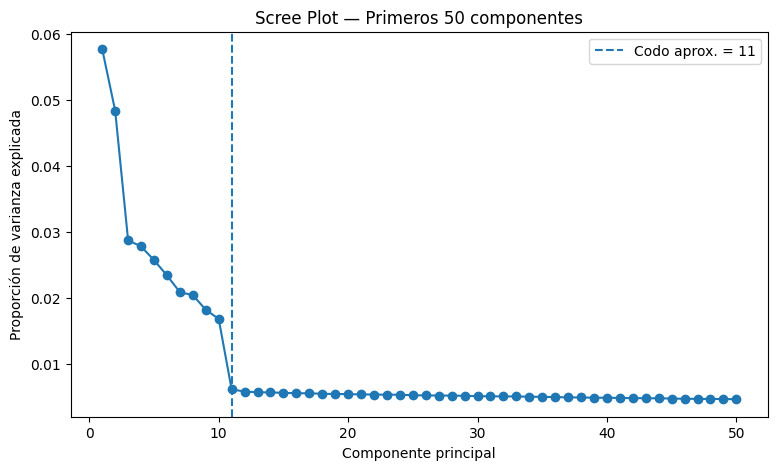

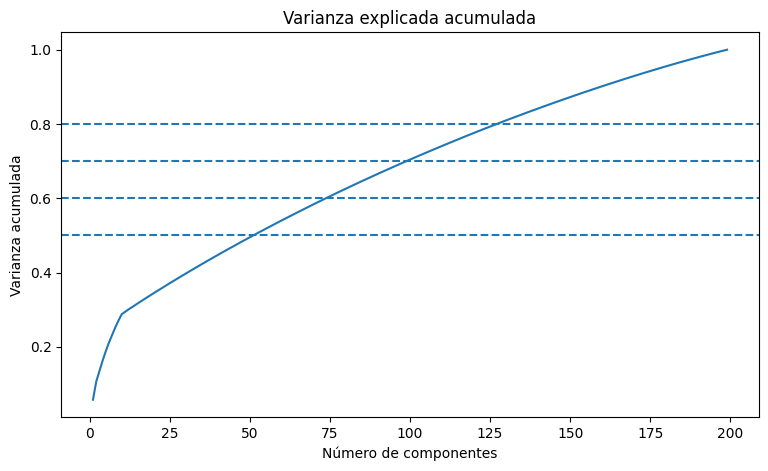

In [9]:
# ============================================================
# 4.1 Gráficos de sedimentación y varianza acumulada
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(resumen_varianza["componente"].head(50), resumen_varianza["varianza_explicada"].head(50), marker="o")
plt.axvline(m_codo, linestyle="--", label=f"Codo aprox. = {m_codo}")
plt.title("Scree Plot — Primeros 50 componentes")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(resumen_varianza["componente"], resumen_varianza["varianza_acumulada"])
for u in [0.50, 0.60, 0.70, 0.80]:
    plt.axhline(u, linestyle="--")
plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.show()

## 5. Rotación Varimax y construcción del espacio factorial

Después de extraer los componentes principales, se aplica una rotación ortogonal **Varimax**. La rotación no cambia la cantidad total de información retenida, pero redistribuye las cargas para facilitar la interpretación de los factores.

La matriz resultante de puntuaciones factoriales tendrá dimensión:

\[
200 \times m
\]

En este desarrollo se usa **m = 10** como solución compacta para clustering.

In [10]:
# ============================================================
# 5. Rotación Varimax y puntuaciones factoriales
# ============================================================

def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    """Rotación Varimax ortogonal."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0

    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        matriz = Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        u, s, vh = np.linalg.svd(matriz)
        R = u @ vh
        d = s.sum()
        if d_old != 0 and d / d_old < 1 + tol:
            break

    return Phi @ R, R

m_retenido = 10

# Cargas PCA: componentes transpuestos * sqrt(varianza)
cargas_pca = componentes_pca[:m_retenido, :].T * np.sqrt(varianza_pca[:m_retenido])
cargas_rotadas, matriz_rotacion = varimax(cargas_pca)

# Puntuaciones rotadas: scores PCA * matriz de rotación
puntuaciones_rotadas = puntuaciones_pca[:, :m_retenido] @ matriz_rotacion

# Para clustering conviene estandarizar las puntuaciones factoriales
Z_factorial = StandardScaler().fit_transform(puntuaciones_rotadas)

columnas_factores = [f"F{i+1}" for i in range(m_retenido)]
df_factores = pd.DataFrame(Z_factorial, columns=columnas_factores)
df_factores.insert(0, "prompt_id", df["prompt_id"].values)

print("Dimensiones del nuevo espacio factorial:", df_factores.shape)
display(df_factores.head())

Dimensiones del nuevo espacio factorial: (200, 11)


,prompt_id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,1,-0.3193,0.7156,0.0936,-1.0592,1.6139,-0.4253,-0.6540,-1.0210,1.1966,0.3133
1,2,-1.5989,1.0310,-0.0381,-1.7790,0.0647,-0.2327,1.5316,0.8516,1.7592,1.0050
2,3,0.4799,-0.8444,0.6063,-0.4314,-0.8173,-0.0496,-0.8807,-0.3145,0.6064,2.1017
3,4,-1.2459,0.3138,0.1612,-0.4276,-2.2356,-1.1833,0.2743,0.5714,0.9717,0.1710
4,5,-2.1394,2.1276,-1.4059,0.0755,-0.2458,0.7980,-0.1562,-1.8048,-1.3383,-1.6144


In [11]:
# ============================================================
# 5.1 Variables con mayor asociación con cada factor rotado
# ============================================================

correlaciones_var_factor = (X_completa_est.T @ Z_factorial) / (X_completa_est.shape[0] - 1)

filas_top = []
for j, factor in enumerate(columnas_factores):
    indices_top = np.argsort(-np.abs(correlaciones_var_factor[:, j]))[:8]
    for idx in indices_top:
        filas_top.append({
            "factor": factor,
            "variable": columnas_variables[idx],
            "correlacion": correlaciones_var_factor[idx, j]
        })

tabla_top_factores = pd.DataFrame(filas_top)
display(tabla_top_factores.round(4))

,factor,variable,correlacion
0,F1,int_metric_1506,-0.7086
1,F1,int_metric_1752,-0.6957
2,F1,int_metric_1337,0.6911
3,F1,int_metric_276,0.6879
4,F1,int_metric_2708,0.6461
...,...,...,...
75,F10,int_metric_2874,0.4542
76,F10,int_metric_1055,-0.4495
77,F10,int_metric_904,0.4271
78,F10,int_metric_1703,-0.4258


## 6. Clustering sobre el espacio factorial

Ahora se realiza clustering sobre las puntuaciones factoriales, no sobre las 3000 variables originales. Esto es importante porque:

- Reduce ruido y redundancia.
- Evita calcular distancias en un espacio excesivamente disperso.
- Hace que K-Means y Ward trabajen sobre dimensiones latentes más estables.
- Permite perfilar los grupos con centroides interpretables.

Se comparan dos enfoques:

1. **K-Means**, método de particionamiento basado en centroides.
2. **Clustering jerárquico aglomerativo con Ward**, método que agrupa observaciones minimizando el incremento de varianza intra-clúster.

In [12]:
# ============================================================
# 6. Evaluación de K-Means y Ward para varios valores de k
# ============================================================

def evaluar_clustering(Z, rango_k=range(2, 11), semilla=123):
    resultados = []

    for k in rango_k:
        modelo_kmeans = KMeans(n_clusters=k, n_init=10, random_state=semilla, algorithm="lloyd")
        etiquetas_kmeans = modelo_kmeans.fit_predict(Z)

        resultados.append({
            "metodo": "KMeans",
            "k": k,
            "silhouette": silhouette_score(Z, etiquetas_kmeans),
            "davies_bouldin": davies_bouldin_score(Z, etiquetas_kmeans),
            "calinski_harabasz": calinski_harabasz_score(Z, etiquetas_kmeans),
            "inercia_sse": modelo_kmeans.inertia_,
        })

        modelo_ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
        etiquetas_ward = modelo_ward.fit_predict(Z)

        resultados.append({
            "metodo": "Ward",
            "k": k,
            "silhouette": silhouette_score(Z, etiquetas_ward),
            "davies_bouldin": davies_bouldin_score(Z, etiquetas_ward),
            "calinski_harabasz": calinski_harabasz_score(Z, etiquetas_ward),
            "inercia_sse": np.nan,
        })

    return pd.DataFrame(resultados)

metricas_cluster = evaluar_clustering(Z_factorial, rango_k=range(2, 11), semilla=SEMILLA)
display(metricas_cluster.round(4))

mejores_silueta = metricas_cluster.sort_values("silhouette", ascending=False).head(10)
print("Mejores soluciones según Silhouette")
display(mejores_silueta.round(4))

,metodo,k,silhouette,davies_bouldin,calinski_harabasz,inercia_sse
0,KMeans,2,0.0835,3.1312,19.2377,1822.8880
1,Ward,2,0.0589,3.8444,12.6951,NaN
2,KMeans,3,0.0816,2.7250,16.8238,1708.2331
3,Ward,3,0.0530,3.2414,12.3843,NaN
4,KMeans,4,0.0848,2.4803,16.3113,1600.4324
5,Ward,4,0.0571,2.9038,12.3067,NaN
6,KMeans,5,0.0860,2.3077,15.2423,1523.6199
7,Ward,5,0.0636,2.6125,12.0920,NaN
8,KMeans,6,0.0868,2.2504,14.7334,1449.5632
9,Ward,6,0.0649,2.3935,12.0281,NaN


Mejores soluciones según Silhouette


,metodo,k,silhouette,davies_bouldin,calinski_harabasz,inercia_sse
14,KMeans,9,0.0902,1.9845,12.8699,1299.5017
10,KMeans,7,0.0896,2.0662,13.9555,1394.8454
16,KMeans,10,0.0895,2.0280,12.3183,1263.0245
12,KMeans,8,0.0890,2.0322,13.5697,1338.0367
8,KMeans,6,0.0868,2.2504,14.7334,1449.5632
6,KMeans,5,0.0860,2.3077,15.2423,1523.6199
4,KMeans,4,0.0848,2.4803,16.3113,1600.4324
0,KMeans,2,0.0835,3.1312,19.2377,1822.8880
2,KMeans,3,0.0816,2.7250,16.8238,1708.2331
17,Ward,10,0.0687,2.1160,10.8695,NaN


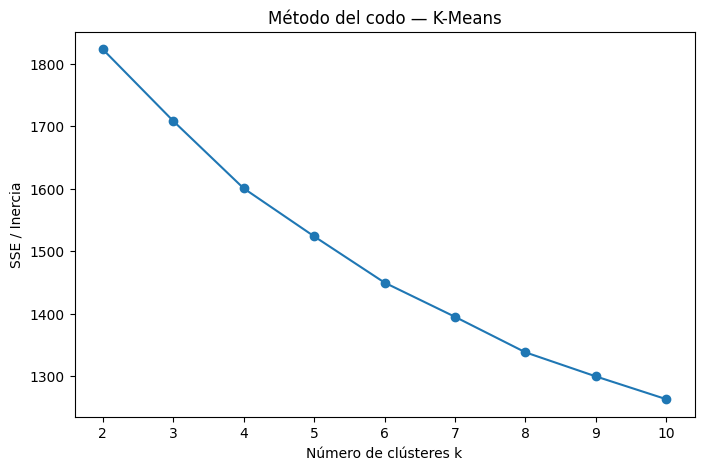

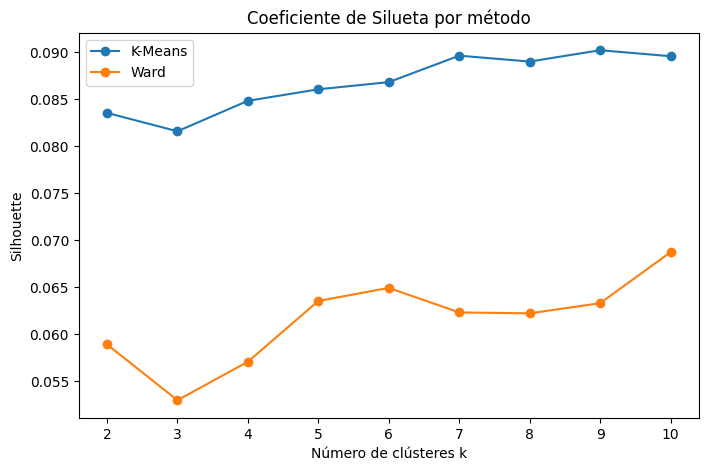

In [13]:
# ============================================================
# 6.1 Gráficos para selección de k
# ============================================================

metricas_kmeans = metricas_cluster[metricas_cluster["metodo"] == "KMeans"]
metricas_ward = metricas_cluster[metricas_cluster["metodo"] == "Ward"]

plt.figure(figsize=(8, 5))
plt.plot(metricas_kmeans["k"], metricas_kmeans["inercia_sse"], marker="o")
plt.title("Método del codo — K-Means")
plt.xlabel("Número de clústeres k")
plt.ylabel("SSE / Inercia")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(metricas_kmeans["k"], metricas_kmeans["silhouette"], marker="o", label="K-Means")
plt.plot(metricas_ward["k"], metricas_ward["silhouette"], marker="o", label="Ward")
plt.title("Coeficiente de Silueta por método")
plt.xlabel("Número de clústeres k")
plt.ylabel("Silhouette")
plt.legend()
plt.show()

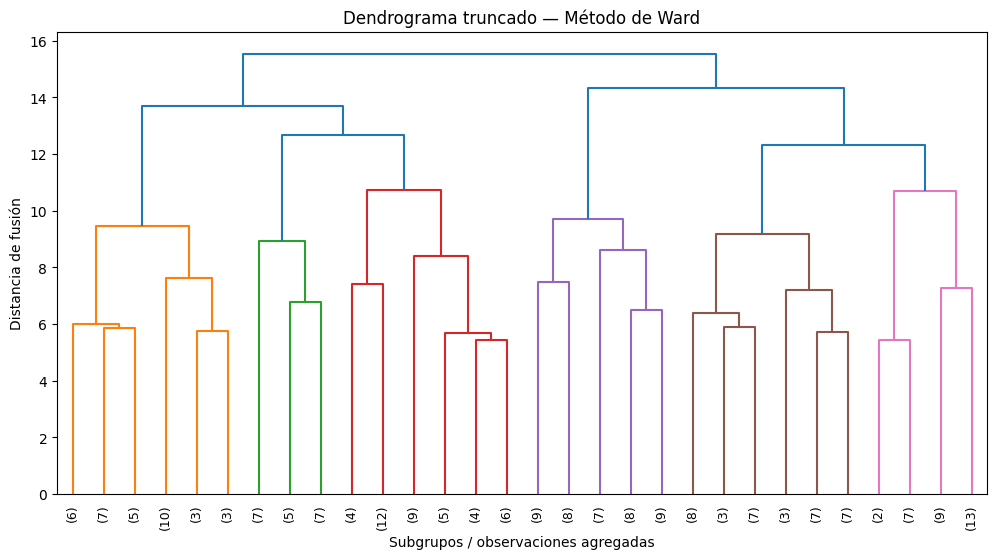

In [14]:
# ============================================================
# 6.2 Dendrograma jerárquico con Ward
# ============================================================

Z_linkage = linkage(Z_factorial, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z_linkage, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.title("Dendrograma truncado — Método de Ward")
plt.xlabel("Subgrupos / observaciones agregadas")
plt.ylabel("Distancia de fusión")
plt.show()

### Selección práctica de la solución final

En el CSV adjunto, K-Means suele superar a Ward en Silhouette, aunque los valores son bajos. Esto indica que los grupos no están perfectamente separados, sino que existen transiciones graduales entre perfiles.

La Silhouette máxima aparece alrededor de valores altos dentro del rango probado, aproximadamente **k = 7 a k = 10**, pero las diferencias son pequeñas. Para una entrega interpretativa, se recomienda trabajar con una solución **k = 4** como solución parsimoniosa: conserva grupos de tamaño razonable y permite conectar los perfiles con las dimensiones humanas de calidad, seguridad, creatividad y sesgo.

Si se quiere seguir estrictamente la máxima Silhouette, se puede cambiar `k_final` por el valor que aparezca en la tabla de mejores soluciones.

In [15]:
# ============================================================
# 7. Ajuste final de K-Means y perfilado de clústeres
# ============================================================

# Solución parsimoniosa recomendada para interpretación.
# Para selección estricta por Silhouette, usar:
# k_final = int(metricas_cluster.query("metodo == 'KMeans'").sort_values("silhouette", ascending=False).iloc[0]["k"])
k_final = 4

modelo_final = KMeans(n_clusters=k_final, n_init=20, random_state=SEMILLA, algorithm="lloyd")
etiquetas_finales = modelo_final.fit_predict(Z_factorial)

sil_final = silhouette_score(Z_factorial, etiquetas_finales)
print(f"k final = {k_final}")
print(f"Silhouette final = {sil_final:.4f}")
print("Tamaño de los clústeres:")
display(pd.Series(etiquetas_finales).value_counts().sort_index().rename("n_prompts").to_frame())

# Centroides en el espacio factorial
centroides_factoriales = (
    pd.DataFrame(Z_factorial, columns=columnas_factores)
    .assign(cluster=etiquetas_finales)
    .groupby("cluster")
    .mean()
)

print("Centroides factoriales")
display(centroides_factoriales.round(3))

k final = 4
Silhouette final = 0.0865
Tamaño de los clústeres:


,n_prompts
0,47
1,51
2,49
3,53


Centroides factoriales


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
cluster,,,,,,,,,,
0,0.7630,0.2140,0.1750,-0.6740,0.2410,-0.4360,-0.9190,0.1470,-0.0020,0.0310
1,0.4250,0.4610,0.0440,0.7500,0.0740,0.4550,0.5840,0.3910,-0.4040,0.0470
2,-0.9370,0.5700,-0.2330,0.1220,-0.7640,-0.1060,0.0240,-0.5390,0.0370,-0.1560
3,-0.2190,-1.1610,0.0180,-0.2370,0.4210,0.0460,0.2320,-0.0080,0.3560,0.0710


Perfil promedio por clúster en constructos humanos estandarizados


,Calidad,Seguridad,Creatividad,Sesgo
cluster,,,,
0,-0.2580,-0.1980,0.3430,0.3840
1,-0.3270,-0.2260,0.4480,0.3610
2,-0.0400,-0.0570,-0.4910,0.0120
3,0.5800,0.4460,-0.2800,-0.6990


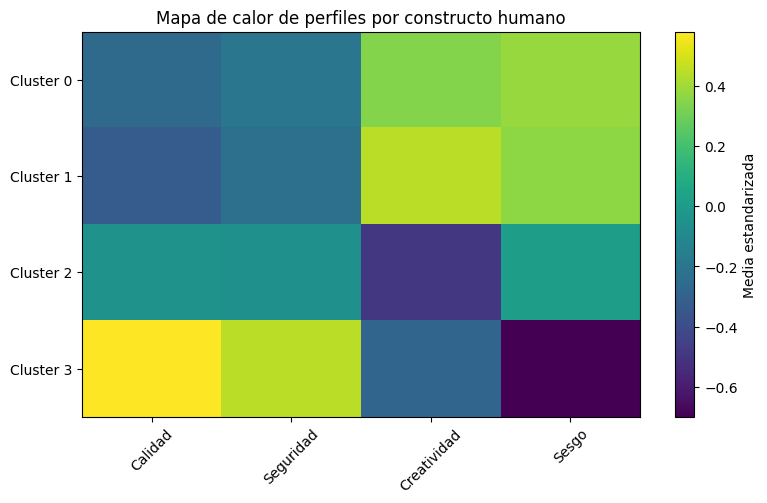

In [16]:
# ============================================================
# 7.1 Perfilado usando constructos humanos originales
# ============================================================

constructos_humanos = {
    "Calidad": columnas_humanas[0:5],
    "Seguridad": columnas_humanas[5:10],
    "Creatividad": columnas_humanas[10:15],
    "Sesgo": columnas_humanas[15:20],
}

# Promedios estandarizados por constructo
humanas_est = pd.DataFrame(
    StandardScaler().fit_transform(df[columnas_humanas]),
    columns=columnas_humanas
)

perfiles_constructos = pd.DataFrame({
    nombre: humanas_est[cols].mean(axis=1)
    for nombre, cols in constructos_humanos.items()
})

perfiles_constructos["cluster"] = etiquetas_finales
perfil_cluster = perfiles_constructos.groupby("cluster").mean()

print("Perfil promedio por clúster en constructos humanos estandarizados")
display(perfil_cluster.round(3))

plt.figure(figsize=(9, 5))
plt.imshow(perfil_cluster.values, aspect="auto")
plt.colorbar(label="Media estandarizada")
plt.xticks(range(len(perfil_cluster.columns)), perfil_cluster.columns, rotation=45)
plt.yticks(range(len(perfil_cluster.index)), [f"Cluster {i}" for i in perfil_cluster.index])
plt.title("Mapa de calor de perfiles por constructo humano")
plt.show()

In [17]:
# ============================================================
# 7.2 Asignación tentativa de nombres interpretativos
# ============================================================

nombres_perfiles = {}
for cluster, fila in perfil_cluster.iterrows():
    calidad = fila["Calidad"]
    seguridad = fila["Seguridad"]
    creatividad = fila["Creatividad"]
    sesgo = fila["Sesgo"]

    if calidad > 0 and seguridad > 0 and sesgo < 0:
        nombre = "Alta calidad y seguridad; bajo riesgo de sesgo"
    elif creatividad > 0 and sesgo > 0:
        nombre = "Alta creatividad con mayor riesgo de sesgo"
    elif creatividad < 0 and abs(sesgo) < 0.3:
        nombre = "Baja creatividad; perfil técnico o neutro"
    elif calidad < 0 and seguridad < 0:
        nombre = "Baja calidad/seguridad; requiere revisión"
    else:
        nombre = "Perfil mixto"

    nombres_perfiles[cluster] = nombre

tabla_nombres = pd.DataFrame({
    "cluster": list(nombres_perfiles.keys()),
    "interpretacion_tentativa": list(nombres_perfiles.values())
})

display(tabla_nombres)

,cluster,interpretacion_tentativa
0,0,Alta creatividad con mayor riesgo de sesgo
1,1,Alta creatividad con mayor riesgo de sesgo
2,2,Baja creatividad; perfil técnico o neutro
3,3,Alta calidad y seguridad; bajo riesgo de sesgo


## 8. Síntesis interpretativa para el informe

A partir de la solución de cuatro clústeres, se puede redactar una interpretación en términos del comportamiento esperado de los prompts:

- Un grupo aparece asociado con **mayor calidad y seguridad**, junto con menor sesgo. Este perfil sería deseable para tareas donde el modelo debe responder de forma confiable, controlada y factual.
- Otro grupo muestra **mayor creatividad**, pero también mayor sesgo. Este perfil puede ser útil para generación abierta, pero requiere controles adicionales de seguridad y alineamiento.
- Un tercer grupo presenta **baja creatividad y valores cercanos al promedio en sesgo**, lo que puede corresponder a prompts más técnicos, cerrados o menos expresivos.
- Un cuarto grupo combina señales menos favorables en calidad/seguridad o patrones internos diferenciados, por lo que puede servir como conjunto prioritario para revisión, fine-tuning o análisis de errores.

La principal ventaja del enfoque Factor-Cluster es que evita agrupar directamente en el espacio original de 3000 variables. En lugar de eso, primero resume la estructura dominante en un espacio latente más manejable y luego identifica perfiles de prompts. Para la evaluación de NLA-7B, estos perfiles pueden ayudar a seleccionar subconjuntos de prompts para fine-tuning diferenciado: prompts seguros y de alta calidad, prompts creativos pero riesgosos, prompts neutros y prompts que requieren intervención prioritaria.

Es importante mencionar que los coeficientes de Silhouette son bajos. Por tanto, los clústeres deben interpretarse como **tipologías exploratorias** y no como clases perfectamente separadas. Esta conclusión es coherente con la naturaleza del clustering en problemas reales de alta dimensionalidad: los límites entre perfiles suelen ser graduales.

In [18]:
# ============================================================
# 9. Exportar resultados principales
# ============================================================

df_resultados = df_factores.copy()
df_resultados["cluster"] = etiquetas_finales

metricas_cluster.to_csv("situacion1_metricas_cluster.csv", index=False)
centroides_factoriales.to_csv("situacion1_centroides_factoriales.csv")
perfil_cluster.to_csv("situacion1_perfiles_constructos.csv")
df_resultados.to_csv("situacion1_puntuaciones_factoriales_clusters.csv", index=False)

print("Archivos exportados:")
print("- situacion1_metricas_cluster.csv")
print("- situacion1_centroides_factoriales.csv")
print("- situacion1_perfiles_constructos.csv")
print("- situacion1_puntuaciones_factoriales_clusters.csv")

Archivos exportados:
- situacion1_metricas_cluster.csv
- situacion1_centroides_factoriales.csv
- situacion1_perfiles_constructos.csv
- situacion1_puntuaciones_factoriales_clusters.csv
